# Last Modified: 2026-04-14 16:15:00

---

# LFP Battery SOH Preprocessing Pipeline (Optimized Batch Version)

This notebook implements a physically-consistent preprocessing framework for the entire dataset:
1. **Phase 1**: Global Physical Cleaning (Unit conversion and noise smoothing for ALL cells)
2. **Phase 2**: Scenario-based Slicing Definition
3. **Phase 2.1**: **Global Slicing Loop (Generate & Cache Raw Segment Pool)**
4. **Phase 3**: 40D HI Extraction Logic Definition
5. **Phase 4**: **Feature Extraction & Scaling (Reuse Sliced Data)**
6. **Phase 5**: Global Tensor Saving

In [3]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from tqdm.notebook import tqdm
import os
import sys
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
from scipy.signal import savgol_filter

# Add project root to sys.path
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_hust, load_mit

## Phase 0: Data Loading

In [4]:
DATASET_TYPE = "hust"
all_cells = load_hust(PROJECT_ROOT / "HUST_data" / "data") if DATASET_TYPE == "hust" else load_mit(PROJECT_ROOT / "MIT_data")
print(f"Loaded {len(all_cells)} cells for {DATASET_TYPE.upper()} dataset.")

HUST Cells: 100%|██████████| 77/77 [00:51<00:00,  1.51it/s]

Loaded 77 cells for HUST dataset.


## Phase 1: Global Physical Cleaning & Unit Conversion

In [5]:
from scipy.signal import savgol_filter
from collections import defaultdict

CLEAN_CACHE_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_clean_chunks"
CLEAN_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_REPORT_PATH = PROJECT_ROOT / "outputs" / "cleaning_report.csv"

def clean_physical_data(df, cid, cyc, cleaning_reports):
    clean_df = df.copy()

    # 1. Unit Conversion
    if "Current (mA)" in clean_df.columns:
        clean_df["Current (A)"] = clean_df["Current (mA)"] / 1000.0

    num_cols = clean_df.select_dtypes(include=[np.number]).columns

    # 2. Outlier detection (Z-score >= 7)
    outlier_mask = pd.Series(False, index=clean_df.index)
    outlier_counts = {col: 0 for col in num_cols}

    for col in num_cols:
        col_std = clean_df[col].std()
        if col_std > 1e-6:
            z_scores = np.abs((clean_df[col] - clean_df[col].mean()) / col_std)
            is_outlier = z_scores >= 7
            if is_outlier.any():
                outlier_counts[col] = is_outlier.sum()
                outlier_mask |= is_outlier

    # 3. Remove outlier rows
    if outlier_mask.any():
        clean_df = clean_df[~outlier_mask].copy()

    # 4. Interpolation and Filling
    if not clean_df.empty:
        for col in num_cols:
            nan_count = clean_df[col].isna().sum()
            o_count = outlier_counts[col]
            if o_count > 0 or nan_count > 0:
                cleaning_reports.append({
                    "cell_id": cid, "cycle": cyc, "feature": col,
                    "outlier_removed": o_count, "interpolated_count": nan_count
                })

        clean_df[num_cols] = clean_df[num_cols].interpolate(method='linear', limit_direction='both')
        clean_df = clean_df.ffill().bfill()

        # 5. Noise Smoothing (Savitzky-Golay)
        v_cols = [c for c in clean_df.columns if "Voltage" in c]
        if v_cols and len(clean_df) >= 11:
            clean_df[v_cols[0]] = savgol_filter(clean_df[v_cols[0]], window_length=11, polyorder=3)

    return clean_df


# 배치 그룹핑 ("1-1" → batch_id=1)
batch_groups = defaultdict(dict)
for cid, cell in all_cells.items():
    batch_id = int(str(cid).split("-")[0])
    batch_groups[batch_id][cid] = cell

all_cleaning_reports = []

for batch_id in sorted(batch_groups.keys()):
    batch_cache_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}.pkl"

    if batch_cache_path.exists():
        print(f"[Clean Batch {batch_id}] Already processed, skipping.")
        # 리포트만 복원
        report_part_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}_report.pkl"
        if report_part_path.exists():
            with open(report_part_path, "rb") as f:
                all_cleaning_reports.extend(pickle.load(f))
        continue

    batch_cells = batch_groups[batch_id]
    batch_cleaned = {}   # {cid: {cyc: clean_df}}
    batch_reports = []

    print(f"\n[Clean Batch {batch_id}] Cleaning {len(batch_cells)} cells: {list(batch_cells.keys())}")

    for cid, cell in batch_cells.items():
        batch_cleaned[cid] = {}
        for cyc in tqdm(list(cell.data.keys()), desc=f"  Cleaning Cell {cid}"):
            batch_cleaned[cid][cyc] = clean_physical_data(cell.data[cyc], cid, cyc, batch_reports)

    # 배치 저장
    print(f"[Clean Batch {batch_id}] Saving cleaned data...")
    with open(batch_cache_path, "wb") as f:
        pickle.dump(batch_cleaned, f, protocol=pickle.HIGHEST_PROTOCOL)

    report_part_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}_report.pkl"
    with open(report_part_path, "wb") as f:
        pickle.dump(batch_reports, f, protocol=pickle.HIGHEST_PROTOCOL)

    all_cleaning_reports.extend(batch_reports)

    del batch_cleaned, batch_reports
    gc.collect()
    print(f"[Clean Batch {batch_id}] Done.")

# 전체 클리닝 리포트 저장
report_df = pd.DataFrame(all_cleaning_reports)
CLEAN_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
report_df.to_csv(CLEAN_REPORT_PATH, index=False)
print(f"Cleaning report saved to {CLEAN_REPORT_PATH}")

[Clean Batch 1] Already processed, skipping.
[Clean Batch 2] Already processed, skipping.
[Clean Batch 3] Already processed, skipping.
[Clean Batch 4] Already processed, skipping.
[Clean Batch 5] Already processed, skipping.
[Clean Batch 6] Already processed, skipping.
[Clean Batch 7] Already processed, skipping.
[Clean Batch 8] Already processed, skipping.
[Clean Batch 9] Already processed, skipping.
[Clean Batch 10] Already processed, skipping.
Cleaning report saved to c:\Users\ksshin\Desktop\ChanminLee\LFP_SOH_prediction\outputs\cleaning_report.csv


## Phase 2: Scenario-based Slicing Definition

In [6]:
def phase2_slice_data(df, start_p=0.0, end_p=1.0, mode="C"): 
    col_i = "Current (A)" if "Current (A)" in df.columns else [c for c in df.columns if "Current" in c][0]
    mode_df = df[df[col_i] > 0.01] if mode == "C" else df[df[col_i] < -0.01]
    if mode_df.empty: return mode_df, 0, (1 if mode == "C" else 0)
    n = len(mode_df)
    s_idx, e_idx = int(n * start_p), int(n * end_p)
    sliced = mode_df.iloc[s_idx:e_idx]
    avg_pos = (start_p + end_p) / 2
    soc_label = -2 if avg_pos <= 0.3 else (-1 if avg_pos <= 0.7 else 0)
    mode_label = 1 if mode == "C" else 0
    return sliced, soc_label, mode_label

## Phase 2.1: Global Slicing Loop (Generate & Cache Raw Segment Pool)

Generate all raw data segments. Saves to a pkl file to skip processing in future runs.

In [7]:
CLEAN_CACHE_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_clean_chunks"
CACHE_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_sliced_chunks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# scen_bounds = {"H": (0.0, 0.3), "M": (0.3, 0.7), "L": (0.7, 1.0), "Random": (0.0, 1.0)}
scen_bounds = {"H": (0.0, 0.3), "M": (0.3, 0.7), "L": (0.7, 1.0)}
lengths = [0.1, 0.2, 0.3]
step = 0.1

# 배치 그룹핑 (cell_id 기준, rul 등 메타만 참조)
batch_groups = defaultdict(dict)
for cid, cell in all_cells.items():
    batch_id = int(str(cid).split("-")[0])
    batch_groups[batch_id][cid] = cell

all_raw_segments = []
full_cycles_map = {}

for batch_id in sorted(batch_groups.keys()):
    slice_cache_path = CACHE_DIR / f"batch_{batch_id}.pkl"
    clean_cache_path = CLEAN_CACHE_DIR / f"batch_clean_{batch_id}.pkl"

    # 슬라이싱 이미 완료된 배치는 로드 후 스킵
    if slice_cache_path.exists():
        print(f"[Slice Batch {batch_id}] Already processed, loading...")
        with open(slice_cache_path, "rb") as f:
            batch_data = pickle.load(f)
        all_raw_segments.extend(batch_data['segments'])
        full_cycles_map.update(batch_data['full_cycles'])
        del batch_data
        gc.collect()
        continue

    assert clean_cache_path.exists(), (
        f"Clean cache not found for batch {batch_id}: {clean_cache_path}\n"
        f"Run the cleaning step first."
    )

    # 클린 데이터 로드
    print(f"\n[Slice Batch {batch_id}] Loading cleaned data from {clean_cache_path}...")
    with open(clean_cache_path, "rb") as f:
        batch_cleaned = pickle.load(f)  # {cid: {cyc: clean_df}}

    batch_cells = batch_groups[batch_id]
    batch_segments = []
    batch_full_cycles = {}

    for cid, cell in batch_cells.items():
        cleaned_cycles = batch_cleaned.get(cid, {})

        for cyc in tqdm(sorted(cleaned_cycles.keys()), desc=f"  Slicing Cell {cid}"):
            df = cleaned_cycles[cyc]

            # float32 변환
            num_cols = df.select_dtypes(include=[np.number]).columns
            df[num_cols] = df[num_cols].astype(np.float32)

            # Full cycle 추출
            full_c_df, _, _ = phase2_slice_data(df, 0.0, 1.0, "C")
            batch_full_cycles[(cid, cyc)] = full_c_df

            for mode in ["C", "D"]:
                for scen_name, (s_bound, e_bound) in scen_bounds.items():
                    for length in lengths:
                        max_start = e_bound - length
                        if max_start < s_bound:
                            continue
                        for start_p in np.arange(s_bound, max_start + 0.0001, step):
                            end_p = start_p + length
                            sliced, soc_l, mode_l = phase2_slice_data(df, start_p, end_p, mode)
                            if not sliced.empty and len(sliced) >= 5:
                                batch_segments.append({
                                    "cell": cid, "cyc": cyc, "df": sliced,
                                    "soc_label": soc_l, "mode_label": mode_l,
                                    "rul": cell.rul[cyc],
                                    "cycle_key": (cid, cyc)
                                })

        gc.collect()

    # 배치 저장
    print(f"[Slice Batch {batch_id}] Saving {len(batch_segments)} segments...")
    with open(slice_cache_path, "wb") as f:
        pickle.dump({'segments': batch_segments, 'full_cycles': batch_full_cycles}, f,
                    protocol=pickle.HIGHEST_PROTOCOL)

    all_raw_segments.extend(batch_segments)
    full_cycles_map.update(batch_full_cycles)

    del batch_cleaned, batch_segments, batch_full_cycles
    gc.collect()
    print(f"[Slice Batch {batch_id}] Done.")

print(f"\nAll batches processed. Total segments: {len(all_raw_segments)}")


[Slice Batch 1] Loading cleaned data from c:\Users\ksshin\Desktop\ChanminLee\LFP_SOH_prediction\outputs\processed\hust_clean_chunks\batch_clean_1.pkl...


  Slicing Cell 1-1:   0%|          | 0/1504 [00:00<?, ?it/s]

  Slicing Cell 1-2:   0%|          | 0/2678 [00:00<?, ?it/s]

  Slicing Cell 1-3:   0%|          | 0/1858 [00:00<?, ?it/s]

  Slicing Cell 1-4:   0%|          | 0/1500 [00:00<?, ?it/s]

...

  Slicing Cell 10-5:   0%|          | 0/2030 [00:00<?, ?it/s]

  Slicing Cell 10-6:   0%|          | 0/2285 [00:00<?, ?it/s]

  Slicing Cell 10-7:   0%|          | 0/1783 [00:00<?, ?it/s]

  Slicing Cell 10-8:   0%|          | 0/1400 [00:00<?, ?it/s]

[Slice Batch 10] Saving 611352 segments...
[Slice Batch 10] Done.

All batches processed. Total segments: 6137124


## Phase 2.2: Global Sliced Data Check

visualize all raw data segments. 

Extracting metadata from sliced batches...


Processing Batches: 100%|██████████| 10/10 [32:08<00:00, 192.90s/it]


=== Sliced Data Summary (hust) ===
Total Segments Generated: 6,137,124
Data Columns per Segment: ['Status', 'Cycle number', 'Current (mA)', 'Voltage (V)', 'Capacity (mAh)', 'Time (s)', 'Current (A)']

--- Segment Counts per Cell ---
  Cell 1-1: 63,168 segments
  Cell 1-2: 112,476 segments
  Cell 1-3: 78,036 segments
  Cell 1-4: 63,000 segments
  Cell 1-5: 82,782 segments
  Cell 1-6: 48,006 segments
  Cell 1-7: 70,476 segments
  Cell 1-8: 95,970 segments
  Cell 10-1: 71,484 segments
  Cell 10-2: 71,274 segments
  Cell 10-3: 77,616 segments
  Cell 10-4: 76,062 segments
  Cell 10-5: 85,260 segments
  Cell 10-6: 95,970 segments
  Cell 10-7: 74,886 segments
  Cell 10-8: 58,800 segments
  Cell 2-2: 111,342 segments
  Cell 2-3: 73,542 segments
  Cell 2-4: 62,958 segments
  Cell 2-5: 58,212 segments
  Cell 2-6: 66,024 segments
  Cell 2-7: 92,484 segments
  Cell 2-8: 62,202 segments
  Cell 3-1: 81,396 segments
  Cell 3-2: 95,886 segments
  Cell 3-3: 69,258 segments
  Cell 3-4: 74,172 segments
 

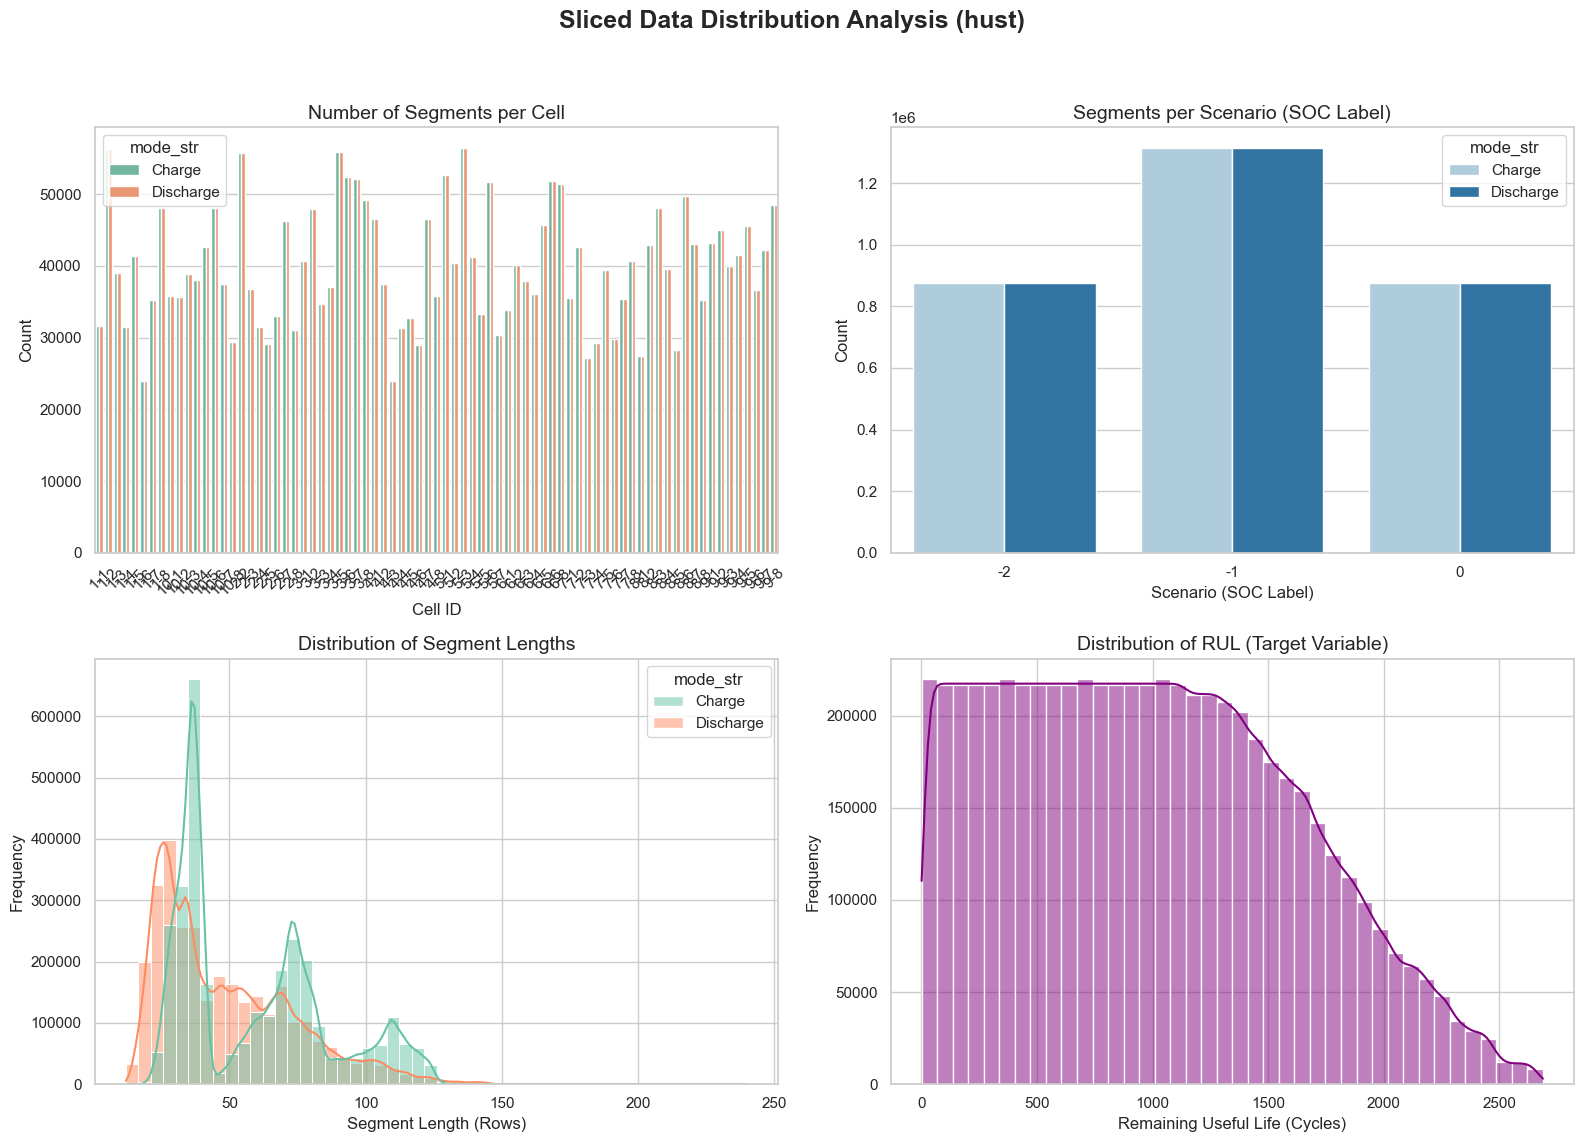

In [15]:
import pandas as pd
import numpy as np
import pickle
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# --- 1. 경로 설정 ---
# PROJECT_ROOT와 DATASET_TYPE이 이전에 정의되어 있다고 가정합니다.
# DATASET_TYPE = "NASA" # 예시
CACHE_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_sliced_chunks"
OUTPUT_REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
OUTPUT_REPORT_DIR.mkdir(parents=True, exist_ok=True)

TXT_REPORT_PATH = OUTPUT_REPORT_DIR / f"{DATASET_TYPE}_slice_summary.txt"
PLOT_SAVE_PATH = OUTPUT_REPORT_DIR / f"{DATASET_TYPE}_slice_distributions.png"

# --- 2. 데이터 로드 및 메타데이터 추출 (메모리 절약) ---
batch_files = sorted(CACHE_DIR.glob("batch_*.pkl"))
assert batch_files, f"No batch files found in {CACHE_DIR}."

meta_records = []
sample_columns = None

print("Extracting metadata from sliced batches...")
for batch_file in tqdm(batch_files, desc="Processing Batches"):
    with open(batch_file, "rb") as f:
        batch_data = pickle.load(f)
        
    segments = batch_data['segments']
    
    for seg in segments:
        df_len = len(seg['df'])
        if sample_columns is None and df_len > 0:
            sample_columns = list(seg['df'].columns)
            
        meta_records.append({
            "cell": seg['cell'],
            "cyc": seg['cyc'],
            "soc_label": seg['soc_label'], # H, M, L 시나리오 맵핑 라벨
            "mode_label": seg['mode_label'], # 1: Charge, 0: Discharge
            "rul": seg['rul'],
            "seg_len": df_len
        })
        
    del batch_data, segments
    gc.collect()

meta_df = pd.DataFrame(meta_records)

# 모드 라벨 문자열 변환 (시각화 용도)
meta_df['mode_str'] = meta_df['mode_label'].map({1: 'Charge', 0: 'Discharge', 'C': 'Charge', 'D': 'Discharge'})
# soc_label이 숫자인 경우 문자열로 변환 (필요시 phase2_slice_data의 로직에 맞게 수정)
meta_df['soc_str'] = meta_df['soc_label'].astype(str) 

# --- 3. 텍스트 리포트 생성 및 저장 ---
report_lines = []
report_lines.append(f"=== Sliced Data Summary ({DATASET_TYPE}) ===")
report_lines.append(f"Total Segments Generated: {len(meta_df):,}")
report_lines.append(f"Data Columns per Segment: {sample_columns}\n")

report_lines.append("--- Segment Counts per Cell ---")
cell_counts = meta_df['cell'].value_counts().sort_index()
for cell, count in cell_counts.items():
    report_lines.append(f"  Cell {cell}: {count:,} segments")

report_lines.append("\n--- Segment Counts per Mode ---")
mode_counts = meta_df['mode_str'].value_counts()
for mode, count in mode_counts.items():
    report_lines.append(f"  {mode}: {count:,} segments")

report_lines.append("\n--- Segment Counts per Scenario (SOC Label) ---")
soc_counts = meta_df['soc_str'].value_counts().sort_index()
for soc, count in soc_counts.items():
    report_lines.append(f"  Scenario '{soc}': {count:,} segments")

report_lines.append("\n--- Segment Length Statistics ---")
report_lines.append(meta_df['seg_len'].describe().to_string())

report_text = "\n".join(report_lines)
print(report_text)

with open(TXT_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)
print(f"\n[Info] Text report saved to: {TXT_REPORT_PATH}")


# --- 4. 시각화 (Plotting) ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Sliced Data Distribution Analysis ({DATASET_TYPE})", fontsize=18, fontweight='bold')

# 1) 셀 별 세그먼트 개수 (Bar Plot)
sns.countplot(data=meta_df, x='cell', hue='mode_str', ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Number of Segments per Cell", fontsize=14)
axes[0, 0].set_xlabel("Cell ID")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) 시나리오(SOC) 및 모드 별 세그먼트 개수
sns.countplot(data=meta_df, x='soc_str', hue='mode_str', ax=axes[0, 1], palette="Paired")
axes[0, 1].set_title("Segments per Scenario (SOC Label)", fontsize=14)
axes[0, 1].set_xlabel("Scenario (SOC Label)")
axes[0, 1].set_ylabel("Count")

# 3) 세그먼트 길이(Time Steps) 분포
sns.histplot(data=meta_df, x='seg_len', hue='mode_str', bins=50, kde=True, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Distribution of Segment Lengths", fontsize=14)
axes[1, 0].set_xlabel("Segment Length (Rows)")
axes[1, 0].set_ylabel("Frequency")

# 4) RUL (잔여 수명) 분포
sns.histplot(data=meta_df, x='rul', bins=40, kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title("Distribution of RUL (Target Variable)", fontsize=14)
axes[1, 1].set_xlabel("Remaining Useful Life (Cycles)")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(PLOT_SAVE_PATH, dpi=300)
print(f"[Info] Plots saved to: {PLOT_SAVE_PATH}")
plt.show()

## Phase 3: 40D Adaptive HI Extraction Logic

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, pearsonr

def extract_40d_hi(df, mode="C", history_df=None):
    # 1. 컬럼 매핑
    v_col = [c for c in df.columns if "Voltage" in c][0]
    i_col = "Current (A)" if "Current (A)" in df.columns else [c for c in df.columns if "Current" in c][0]
    t_col = [c for c in df.columns if "Time" in c][0]
    temp_col = [c for c in df.columns if "Temperature" in c]
    
    v = df[v_col].values
    i = np.abs(df[i_col].values)  # 충/방전 방향성 무관하게 크기로 통일
    t = df[t_col].values
    temp = df[temp_col[0]].values if temp_col else np.full_like(v, 25.0)
    
    # 2. 시간/용량 변화량 (Safe Diff)
    # 첫 번째 값을 복사해서 prepend하여 배열 길이 유지 (적분용)
    dt_full = np.diff(t, prepend=t[0])
    dt_diff = np.where(np.diff(t) > 0, np.diff(t), 1e-6) # 미분용 (길이 N-1)
    
    his = {}
    
    # ==========================================
    # [Category 1] 공통 HI (Common) - 14개
    # ==========================================
    his["c1_mean_v"] = np.mean(v)
    his["c1_var_v"] = np.var(v)
    his["c1_skew_v"] = skew(v) if len(np.unique(v)) > 1 else 0.0
    his["c1_kurt_v"] = kurtosis(v) if len(np.unique(v)) > 1 else 0.0
    his["c1_mean_t"] = np.mean(temp)
    his["c1_delta_t"] = np.max(temp) - np.min(temp)
    his["c1_dtdt"] = np.mean(np.diff(temp) / dt_diff)
    his["c1_mean_i"] = np.mean(i)
    his["c1_var_i"] = np.var(i)
    
    # Histogram 기반 Sample Entropy 근사
    p_v = np.histogram(v, bins=10, density=True)[0]
    his["c1_ent_v"] = -np.sum(p_v * np.log(p_v + 1e-6))
    p_t = np.histogram(temp, bins=10, density=True)[0]
    his["c1_ent_t"] = -np.sum(p_t * np.log(p_t + 1e-6))
    
    # 동적 커플링 (상관계수) - 표준편차가 0인 상수 배열 예외 처리
    his["c1_corr_vi"] = pearsonr(v, i)[0] if np.std(v) > 1e-6 and np.std(i) > 1e-6 else 0.0
    his["c1_corr_vt"] = pearsonr(v, temp)[0] if np.std(v) > 1e-6 and np.std(temp) > 1e-6 else 0.0
    
    # 에너지 효율 지표 (Delta E / Delta Q)
    his["c1_de_dq"] = np.sum(v * i * dt_full) / (np.sum(i * dt_full) + 1e-6)

    # ==========================================
    # C2, C3 초기화 (사용 안 하는 카테고리는 0으로 패딩)
    # ==========================================
    for j in range(1, 14): 
        his[f"c2_dis_{j}"] = his[f"c3_cha_{j}"] = 0.0

    # ==========================================
    # 공통 파생 변수 (미분/적분 베이스)
    # ==========================================
    dvdt = np.diff(v) / dt_diff
    d2vdt2 = np.diff(dvdt) / np.where(dt_diff[1:] > 0, dt_diff[1:], 1e-6) if len(dvdt) > 1 else np.array([0.0])
    seg_energy = np.sum(v * i * dt_full) / 3600.0  # Wh
    seg_capacity = np.sum(i * dt_full) / 3600.0    # Ah
    dq = (i[1:] * dt_diff) / 3600.0 # Ah (길이 N-1)

    # ==========================================
    # [Category 2] 방전 전용 HI (Discharge) - 13개
    # ==========================================
    if mode == "D":
        his["c2_dis_1"] = np.mean(dvdt)      # 평균 강하율
        his["c2_dis_2"] = np.var(dvdt)       # 강하율 분산
        his["c2_dis_3"] = np.mean(d2vdt2)    # 가속 강하도 (곡률 파악용)
        his["c2_dis_4"] = np.sum((np.max(v) - v) * dt_full) # 전압 강하 적분 면적
        
        # Local DCIR (전류 변화가 유의미할 때의 전압 변화 비율)
        di = np.diff(i)
        valid_di = np.abs(di) > 0.01 # 10mA 이상의 전류 변화가 있는 스텝만
        his["c2_dis_5"] = np.mean(np.abs(np.diff(v)[valid_di] / di[valid_di])) if np.any(valid_di) else 0.0
        
        his["c2_dis_6"] = seg_energy
        his["c2_dis_7"] = seg_capacity
        
        # 지역적 역용량 기울기 (dV/dQ) - Stiffness
        dvdq = np.diff(v) / np.where(dq > 0, dq, 1e-6)
        his["c2_dis_8"] = np.mean(dvdq)
        his["c2_dis_9"] = np.var(dvdq)
        
        his["c2_dis_10"] = np.min(v) / (np.max(v) + 1e-6) # V ratio
        his["c2_dis_11"] = (temp[-1] - temp[0]) / (seg_capacity + 1e-6) # 용량당 발열률
        his["c2_dis_12"] = np.sum(np.abs(np.diff(dvdt))) # 방전 곡선 거칠기 (SAD of dV/dt)
        his["c2_dis_13"] = np.sum(v * dt_full) / (np.mean(i) + 1e-6) # 전류 정규화 전압 면적

    # ==========================================
    # [Category 3] 충전 전용 HI (Charge) - 13개
    # ==========================================
    elif mode == "C":
        his["c3_cha_1"] = np.mean(dvdt)      # 평균 상승률
        his["c3_cha_2"] = np.var(dvdt)       # 상승률 분산
        his["c3_cha_3"] = np.mean(d2vdt2)    # 가속 상승도
        his["c3_cha_4"] = np.sum((v - np.min(v)) * dt_full) # 전압 상승 적분 면적
        
        # 지역적 증분 용량 (Local IC, dQ/dV)
        # 충전 중엔 전압이 오르므로 dV > 0 인 구간만 유효
        dv_pos = np.where(np.diff(v) > 0.001, np.diff(v), 1e-6)
        dqdv = dq / dv_pos
        his["c3_cha_5"] = np.mean(dqdv)
        his["c3_cha_6"] = np.var(dqdv)
        
        his["c3_cha_7"] = seg_energy
        his["c3_cha_8"] = seg_capacity
        
        his["c3_cha_9"] = np.max(v) / (np.min(v) + 1e-6) # V ratio
        his["c3_cha_10"] = (temp[-1] - temp[0]) / (seg_capacity + 1e-6) # 용량당 발열률
        his["c3_cha_11"] = np.sum(np.abs(np.diff(dvdt))) # 충전 곡선 거칠기 (리튬 플레이팅 감지 프록시)
        
        # 충전 수용성 프록시 (I_mean / Mean(dV/dt))
        # 전압 급증 없이 전류를 얼마나 잘 먹는지
        his["c3_cha_12"] = np.mean(i) / (np.abs(np.mean(dvdt)) + 1e-6) 
        
        # 전압 궤적 곡률 엔트로피
        p_dvdt = np.histogram(dvdt, bins=10, density=True)[0]
        his["c3_cha_13"] = -np.sum(p_dvdt * np.log(p_dvdt + 1e-6))

    # 최종 40D Series 반환
    return pd.Series(his)

## Phase 4: Feature Extraction & Scaling (Reusing Sliced Segments)

This phase iterates through the pool from Phase 2.1. No redundant slicing is performed here.

In [14]:
import pandas as pd
import numpy as np
import pickle
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ---------------------------------------------------------
# [추가됨] 첫 번째 셀 시각화를 위한 헬퍼 함수
# ---------------------------------------------------------
def plot_first_cell_analysis(cell_id, collected_data):
    print(f"\n[Visualization] Plotting exploratory analysis for the first cell: {cell_id}")
    
    # 리스트 딕셔너리를 DataFrame으로 변환
    df_vis = pd.DataFrame(collected_data)
    
    # 40차원 HI 배열을 개별 컬럼으로 확장 (HI_0 ~ HI_39)
    hi_df = pd.DataFrame(df_vis['hi'].tolist())
    hi_df.columns = [f"HI_{i}" for i in range(hi_df.shape[1])]
    df_vis = pd.concat([df_vis.drop('hi', axis=1), hi_df], axis=1)

    # 2x2 서브플롯 구성
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle(f"Exploratory Data Analysis for Cell {cell_id} (After HI Extraction)", fontsize=16, fontweight='bold')

    # 1. 세그먼트 길이 분포 (Charge vs Discharge)
    # 데이터 시퀀스 길이가 어떻게 분포하는지 파악하여 향후 패딩(Padding) 전략 수립에 활용
    sns.histplot(data=df_vis, x='seg_len', hue='mode', kde=True, bins=30, ax=axes[0, 0], palette="Set2")
    axes[0, 0].set_title("1. Segment Length Distribution (C vs D)")
    axes[0, 0].set_xlabel("Segment Length (Time Steps)")

    # 2. 사이클에 따른 특정 HI(예: HI_0)의 트렌드 변화
    # 추출된 차원이 사이클(열화)에 따라 뚜렷한 경향성을 띄는지 확인
    sns.scatterplot(data=df_vis, x='cyc', y='HI_0', hue='mode', alpha=0.7, ax=axes[0, 1], palette="Set1")
    axes[0, 1].set_title("2. Trend of Top Feature (HI_0) over Cycles")
    axes[0, 1].set_xlabel("Cycle")
    axes[0, 1].set_ylabel("HI_0 Value")

    # 3. 상위 10개 HI Feature 간의 상관관계 히트맵
    # 다중공선성(Multicollinearity) 확인 및 차원 축소 필요성 판단
    cols_to_corr = [c for c in df_vis.columns if c.startswith('HI_')][:10]
    corr_matrix = df_vis[cols_to_corr].corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=axes[1, 0], square=True)
    axes[1, 0].set_title("3. Correlation Heatmap of Top 10 HIs")

    # 4. RUL 궤적에 따른 특정 HI(예: HI_0)의 매핑
    # RUL 예측 모델(Regression)을 학습하기 전, HI와 Target(RUL) 간의 매핑 형태가 선형인지 비선형인지 확인
    sns.scatterplot(data=df_vis, x='rul', y='HI_0', hue='cyc', palette='viridis', alpha=0.8, ax=axes[1, 1])
    axes[1, 1].set_title("4. Feature Degradation Trajectory (HI_0 vs RUL)")
    axes[1, 1].set_xlabel("Remaining Useful Life (RUL)")
    axes[1, 1].set_ylabel("HI_0 Value")
    axes[1, 1].invert_xaxis()  # 배터리 열화 관찰을 위해 RUL은 역순(감소)으로 표시

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------------
# 기존 추출 및 스케일링 로직
# ---------------------------------------------------------
SCALING_METHOD = "zscore"  # Choose 'zscore' or 'minmax'

HI_CACHE_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_sliced_chunks"

HI_FINAL_CACHE_PATH = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_feature_pool_cache.pkl"


# HI_CACHE_DIR, HI_FINAL_CACHE_PATH 등은 기존과 동일하다고 가정
if HI_FINAL_CACHE_PATH.exists():
    print(f"Loading feature pool from cache: {HI_FINAL_CACHE_PATH}")
    with open(HI_FINAL_CACHE_PATH, "rb") as f:
        hi_cache = pickle.load(f)
    feature_pool = hi_cache['feature_pool']
    scaler = hi_cache['scaler']
    print(f"Successfully loaded {len(feature_pool)} features.")

else:
    batch_files = sorted(HI_CACHE_DIR.glob("batch_*.pkl"))
    assert batch_files, f"No batch files found in {HI_CACHE_DIR}. Run slicing step first."

    cell_histories = {cid: pd.DataFrame() for cid in all_cells.keys()}
    feature_pool = []

    # --- [추가됨] 시각화 트리거 상태 관리 변수 ---
    has_plotted = False
    target_cell = None
    target_cell_data = []

    # --- Phase 4-1: 배치별 HI 추출 ---
    for batch_file in sorted(batch_files):
        batch_id = batch_file.stem  
        print(f"\n[{batch_id}] Extracting HI features...")

        with open(batch_file, "rb") as f:
            batch_data = pickle.load(f)

        batch_segments = batch_data['segments']

        for item in tqdm(batch_segments, desc=f"  Phase 4: HI Extraction [{batch_id}]"):
            cid = item['cell']
            mode_str = "C" if item['mode_label'] == 1 else "D"
            
            # (가정) extract_40d_hi 함수가 존재한다고 전제
            hi = extract_40d_hi(item['df'], mode_str, cell_histories[cid])

            # ---------------------------------------------------------
            # [추가됨] 첫 번째 셀 데이터 수집 및 시각화 트리거 로직
            # ---------------------------------------------------------
            if not has_plotted:
                # 1. 최초 셀 아이디 등록
                if target_cell is None:
                    target_cell = cid

                # 2. 타겟 셀 데이터 수집
                if cid == target_cell:
                    target_cell_data.append({
                        'cyc': item['cyc'],
                        'hi': hi,
                        'mode': mode_str,
                        'seg_len': len(item['df']), # Time-series 길이
                        'rul': item['rul']
                    })
                # 3. 셀이 변경되는 순간 (첫 번째 셀의 모든 세그먼트 처리 완료)
                elif cid != target_cell:
                    plot_first_cell_analysis(target_cell, target_cell_data)
                    has_plotted = True
                    target_cell_data.clear() # 메모리 해제
            # ---------------------------------------------------------

            feature_pool.append({
                "cell": cid, "cyc": item['cyc'], "raw_x": hi,
                "soc_label": item['soc_label'], "mode_label": item['mode_label'],
                "y": item['rul']
            })

        del batch_data, batch_segments
        gc.collect()

    # --- Phase 4-2: 전체 기준으로 스케일러 fit & transform ---
    print(f"\nTotal features extracted: {len(feature_pool)}")
    print(f"Fitting scaler ({SCALING_METHOD}) on full feature pool...")

    raw_x_df = pd.DataFrame([x['raw_x'] for x in feature_pool])
    scaler = StandardScaler() if SCALING_METHOD == "zscore" else MinMaxScaler()
    scaled_x = scaler.fit_transform(raw_x_df)

    for i, item in enumerate(feature_pool):
        item['scaled_x'] = scaled_x[i]

    del raw_x_df, scaled_x
    gc.collect()

    # --- Phase 4-3: 캐시 저장 ---
    print(f"Saving feature pool to {HI_FINAL_CACHE_PATH}...")
    with open(HI_FINAL_CACHE_PATH, "wb") as f:
        pickle.dump({'feature_pool': feature_pool, 'scaler': scaler}, f,
                    protocol=pickle.HIGHEST_PROTOCOL)
    print("Feature pool cache saved successfully.")

print(f"Extraction and Scaling ({SCALING_METHOD}) complete. Total: {len(feature_pool)} items.")


[batch_1] Extracting HI features...


KeyboardInterrupt: 

### 아래는 부분 데이터 저장 로직 적용 후 (메모리 모자라면 사용)

In [ ]:
import pandas as pd
import numpy as np
import pickle
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ---------------------------------------------------------
# 첫 번째 셀 시각화를 위한 헬퍼 함수 (기존과 동일)
# ---------------------------------------------------------
def plot_first_cell_analysis(cell_id, collected_data):
    print(f"\n[Visualization] Plotting exploratory analysis for the first cell: {cell_id}")
    df_vis = pd.DataFrame(collected_data)
    
    hi_df = pd.DataFrame(df_vis['hi'].tolist())
    hi_df.columns = [f"HI_{i}" for i in range(hi_df.shape[1])]
    df_vis = pd.concat([df_vis.drop('hi', axis=1), hi_df], axis=1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle(f"Exploratory Data Analysis for Cell {cell_id} (After HI Extraction)", fontsize=16, fontweight='bold')

    sns.histplot(data=df_vis, x='seg_len', hue='mode', kde=True, bins=30, ax=axes[0, 0], palette="Set2")
    axes[0, 0].set_title("1. Segment Length Distribution (C vs D)")
    
    sns.scatterplot(data=df_vis, x='cyc', y='HI_0', hue='mode', alpha=0.7, ax=axes[0, 1], palette="Set1")
    axes[0, 1].set_title("2. Trend of Top Feature (HI_0) over Cycles")
    
    cols_to_corr = [c for c in df_vis.columns if c.startswith('HI_')][:10]
    sns.heatmap(df_vis[cols_to_corr].corr(), annot=False, cmap='coolwarm', center=0, ax=axes[1, 0], square=True)
    axes[1, 0].set_title("3. Correlation Heatmap of Top 10 HIs")
    
    sns.scatterplot(data=df_vis, x='rul', y='HI_0', hue='cyc', palette='viridis', alpha=0.8, ax=axes[1, 1])
    axes[1, 1].set_title("4. Feature Degradation Trajectory (HI_0 vs RUL)")
    axes[1, 1].invert_xaxis()  

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------------
# 메모리 절약형 추출 및 배치 분할 스케일링 로직
# ---------------------------------------------------------
SCALING_METHOD = "zscore"  # Choose 'zscore' or 'minmax'

HI_CACHE_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_sliced_chunks"
# 변경됨: 단일 캐시 파일이 아닌, 배치별 저장 폴더 생성
FEATURE_BATCH_DIR = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_feature_batches"
FEATURE_BATCH_DIR.mkdir(parents=True, exist_ok=True)
SCALER_CACHE_PATH = PROJECT_ROOT / "outputs" / "processed" / f"{DATASET_TYPE}_scaler.pkl"

batch_files = sorted(HI_CACHE_DIR.glob("batch_*.pkl"))
assert batch_files, f"No batch files found in {HI_CACHE_DIR}. Run slicing step first."

cell_histories = {cid: pd.DataFrame() for cid in all_cells.keys()}

has_plotted = False
target_cell = None
target_cell_data = []

# 스케일러 초기화 (partial_fit을 위해)
scaler = StandardScaler() if SCALING_METHOD == "zscore" else MinMaxScaler()

# =========================================================
# PASS 1: HI 추출 & 임시 저장 & 스케일러 점진적 학습 (partial_fit)
# =========================================================
print(f"\n--- PASS 1: Feature Extraction & Scaler Fitting ---")
total_items_extracted = 0

for batch_file in sorted(batch_files):
    batch_id = batch_file.stem  
    print(f"\n[{batch_id}] Extracting HI features...")

    with open(batch_file, "rb") as f:
        batch_data = pickle.load(f)

    batch_segments = batch_data['segments']
    batch_feature_pool = []  # 배치 단위 리스트

    for item in tqdm(batch_segments, desc=f"  Extracting [{batch_id}]"):
        cid = item['cell']
        mode_str = "C" if item['mode_label'] == 1 else "D"
        
        hi = extract_40d_hi(item['df'], mode_str, cell_histories[cid])

        # 시각화 트리거 로직
        if not has_plotted:
            if target_cell is None:
                target_cell = cid
            if cid == target_cell:
                target_cell_data.append({
                    'cyc': item['cyc'], 'hi': hi, 'mode': mode_str,
                    'seg_len': len(item['df']), 'rul': item['rul']
                })
            elif cid != target_cell:
                plot_first_cell_analysis(target_cell, target_cell_data)
                has_plotted = True
                target_cell_data.clear()

        batch_feature_pool.append({
            "cell": cid, "cyc": item['cyc'], "raw_x": hi,
            "soc_label": item['soc_label'], "mode_label": item['mode_label'],
            "y": item['rul']
        })

    # 배치 단위 스케일러 학습 (partial_fit)
    raw_x_batch = [x['raw_x'] for x in batch_feature_pool]
    scaler.partial_fit(raw_x_batch)

    # 추출된 Raw 배치를 디스크에 임시 저장 (Pass 2에서 사용)
    raw_batch_path = FEATURE_BATCH_DIR / f"raw_{batch_id}.pkl"
    with open(raw_batch_path, "wb") as f:
        pickle.dump(batch_feature_pool, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    total_items_extracted += len(batch_feature_pool)
    
    # 메모리 해제
    del batch_data, batch_segments, batch_feature_pool, raw_x_batch
    gc.collect()

# =========================================================
# PASS 2: 최종 스케일링 적용 (transform) 및 배치 최종 저장
# =========================================================
print(f"\n--- PASS 2: Applying Scaler & Final Batch Saving ---")
raw_batch_files = sorted(FEATURE_BATCH_DIR.glob("raw_batch_*.pkl"))

for raw_file in raw_batch_files:
    batch_id = raw_file.stem.replace("raw_", "") # e.g., "batch_1"
    
    with open(raw_file, "rb") as f:
        batch_feature_pool = pickle.load(f)
        
    print(f"Applying scaling to [{batch_id}] ({len(batch_feature_pool)} items)...")
    
    raw_x_batch = [x['raw_x'] for x in batch_feature_pool]
    scaled_x_batch = scaler.transform(raw_x_batch)
    
    for i, item in enumerate(batch_feature_pool):
        item['scaled_x'] = scaled_x_batch[i]
        
    # 스케일링이 완료된 최종 배치 저장
    final_batch_path = FEATURE_BATCH_DIR / f"final_{batch_id}.pkl"
    with open(final_batch_path, "wb") as f:
        pickle.dump(batch_feature_pool, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    # 디스크 용량 절약을 위해 임시(Raw) 파일 삭제
    raw_file.unlink()
    
    del batch_feature_pool, raw_x_batch, scaled_x_batch
    gc.collect()

# 완성된 스케일러 모델 별도 저장
with open(SCALER_CACHE_PATH, "wb") as f:
    pickle.dump(scaler, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nExtraction and Batch Scaling ({SCALING_METHOD}) complete.")
print(f"Total items processed: {total_items_extracted}")
print(f"Final batch files saved to: {FEATURE_BATCH_DIR}")
print(f"Fitted scaler saved to: {SCALER_CACHE_PATH}")

## Phase 5: Final Saving

In [ ]:
def save_processed_dataset(pool, dataset_type):
    out_path = PROJECT_ROOT / "outputs" / "processed" / f"{dataset_type}_optimized_tensors.pkl"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    final_data = []
    for item in pool:
        final_data.append({
            "cell": item['cell'], "cyc": item['cyc'], 
            "x": item['scaled_x'], "soc_label": item['soc_label'], 
            "mode_label": item['mode_label'], "y": item['y']
        })
    with open(out_path, "wb") as f: pickle.dump(final_data, f)
    print(f"Saved to {out_path}")

save_processed_dataset(feature_pool, DATASET_TYPE)